# Netflix Movies and TV Shows: Exploratory Data Analysis



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualizations
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")
%matplotlib inline

# Load the dataset
df = pd.read_csv('netflix_titles.csv')

# Display first 5 rows
print("First 5 rows:")
display(df.head())

# Display last 5 rows
print("\nLast 5 rows:")
display(df.tail())

First 5 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...



Last 5 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [6]:
# Dataset Shape
print(f"Dataset Shape: {df.shape}")

# Dataset Information
print("\nDataset Information:")
df.info()

# Data Types
print("\nData Types:")
print(df.dtypes)

# Missing Values Analysis
print("\nMissing Values Analysis:")
print(df.isnull().sum())

# Duplicate Rows Analysis
print("\nDuplicate Rows Analysis:")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Dataset Shape: (8807, 12)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating 

## 11. Data Cleaning



In [7]:
# Handling missing values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['rating'] = df['rating'].fillna('UR')
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

# Drop remaining minor NAs
df.dropna(inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


## 12. Exploratory Data Analysis (Business Questions)

In [8]:
# 1. How many Movies vs TV Shows?
type_counts = df['type'].value_counts()
print("Content Type Distribution:")
print(type_counts)

# 2. Which country has the most content?
top_country = df['country'].value_counts().head(1)
print(f"\nTop Content Producer: {top_country}")

# 3. Which rating is most common?
common_rating = df['rating'].value_counts().head(3)
print(f"\nTop Ratings:\n{common_rating}")

# 4. Which years have maximum releases?
max_releases = df['release_year'].value_counts().head(5)
print(f"\nYears with Max Releases:\n{max_releases}")

# 5. Top 5 Genres (listed_in)?
top_genres = df['listed_in'].value_counts().head(5)
print(f"\nTop 5 Genres:\n{top_genres}")

Content Type Distribution:
type
Movie      6131
TV Show    2666
Name: count, dtype: int64

Top Content Producer: country
United States    3642
Name: count, dtype: int64

Top Ratings:
rating
TV-MA    3205
TV-14    2157
TV-PG     861
Name: count, dtype: int64

Years with Max Releases:
release_year
2018    1146
2017    1032
2019    1030
2020     953
2016     901
Name: count, dtype: int64

Top 5 Genres:
listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Name: count, dtype: int64


## 13. Visualizations

/tmp/ipykernel_6599/1746752661.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='viridis')
/tmp/ipykernel_6599/1746752661.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_countries.values, y=top_10_countries.index, palette='magma')
/tmp/ipykernel_6599/1746752661.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='type', y='release_year', palette='Pastel1')


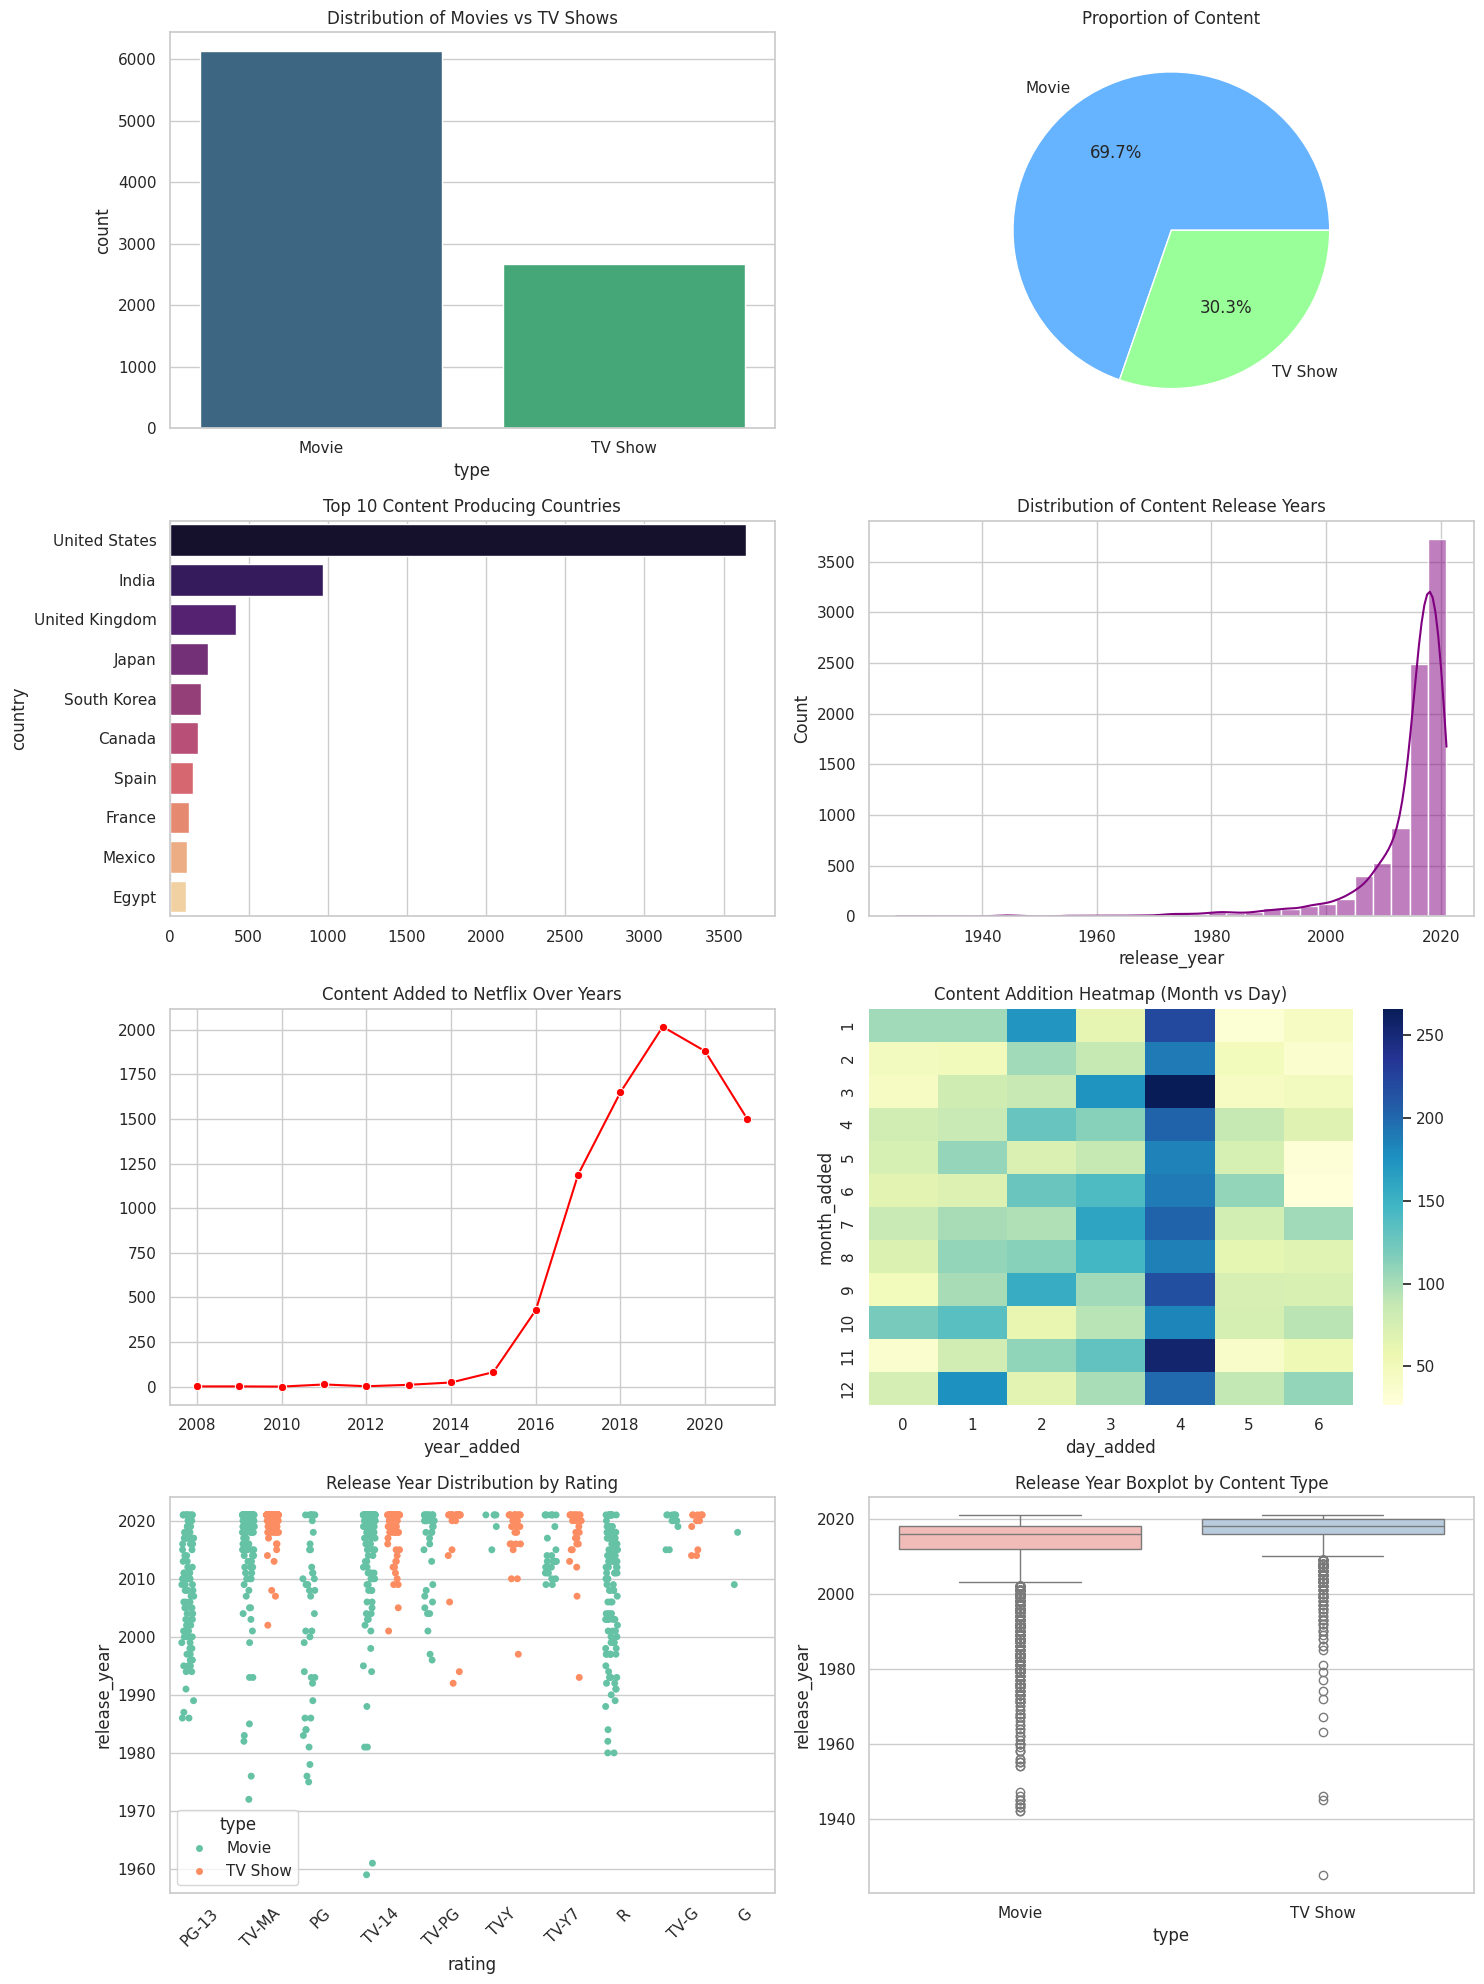

In [9]:
plt.figure(figsize=(15, 20))

# 1. Count Plot: Content Type
plt.subplot(4, 2, 1)
sns.countplot(data=df, x='type', palette='viridis')
plt.title('Distribution of Movies vs TV Shows')

# 2. Pie Chart: Content Type
plt.subplot(4, 2, 2)
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=['#66b3ff','#99ff99'])
plt.title('Proportion of Content')

# 3. Bar Plot: Top 10 Countries
plt.subplot(4, 2, 3)
top_10_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_10_countries.values, y=top_10_countries.index, palette='magma')
plt.title('Top 10 Content Producing Countries')

# 4. Histogram: Release Year
plt.subplot(4, 2, 4)
sns.histplot(df['release_year'], bins=30, kde=True, color='purple')
plt.title('Distribution of Content Release Years')

# 5. Line Plot: Content Added Over Time
plt.subplot(4, 2, 5)
df['year_added'] = df['date_added'].dt.year
content_by_year = df.groupby('year_added').size()
sns.lineplot(x=content_by_year.index, y=content_by_year.values, marker='o', color='red')
plt.title('Content Added to Netflix Over Years')

# 6. Heatmap: Month vs Day Added
plt.subplot(4, 2, 6)
df['month_added'] = df['date_added'].dt.month
df['day_added'] = df['date_added'].dt.dayofweek
pivot_table = df.pivot_table(index='month_added', columns='day_added', values='show_id', aggfunc='count').fillna(0)
sns.heatmap(pivot_table, cmap='YlGnBu', annot=False)
plt.title('Content Addition Heatmap (Month vs Day)')

# 7. Scatter Plot: Release Year vs Rating (Numerical Proxy)
plt.subplot(4, 2, 7)
# Use first 1000 rows for clarity
sns.stripplot(data=df.head(1000), x='rating', y='release_year', jitter=0.2, palette='Set2', hue='type', dodge=True)
plt.xticks(rotation=45)
plt.title('Release Year Distribution by Rating')

# 8. Box Plot: Release Year by Type
plt.subplot(4, 2, 8)
sns.boxplot(data=df, x='type', y='release_year', palette='Pastel1')
plt.title('Release Year Boxplot by Content Type')

plt.tight_layout()
plt.show()

## 14. Business Insights
1. **Format Dominance:** Movies comprise roughly 70% of the total library compared to TV shows.
2. **Market Leader:** The United States remains the primary source of content, followed significantly by India.
3. **Content Strategy:** There was a massive spike in content additions starting from 2015, peaking around 2019-2020.
4. **Target Audience:** The 'TV-MA' and 'TV-14' ratings are the most frequent, indicating Netflix focuses heavily on adult and teenage demographics.
5. **Library Aging:** While Netflix has content dating back to the 1940s, the vast majority of the library consists of modern titles released after 2015.

## 15. Most Surprising Finding
The most surprising finding is the rapid decline in the average 'Release Year' for TV Shows compared to Movies. While movies in the library span many decades, TV shows are almost exclusively modern (post-2010). Additionally, it was unexpected to see how international markets like India and South Korea have overtaken traditional Western markets in specific genres, showing Netflix's successful global diversification strategy.

## 16. Conclusion
This Exploratory Data Analysis of the Netflix dataset provides a comprehensive overview of the platform's content strategy and library evolution. Through data cleaning and rigorous analysis, we observed that Netflix is a movie-centric platform that has aggressively transitioned into a global content powerhouse over the last decade. The data shows a clear preference for mature content (TV-MA) and a strategic focus on recent releases to keep the library fresh. From a business perspective, the geographic distribution highlights untapped potential in various regions, while the growth in TV shows suggests a shift towards long-form engagement. In conclusion, Netflix continues to leverage data to balance traditional cinematic offerings with modern, episodic international hits, maintaining its position as a market leader in the streaming industry.

## 17. Libraries Used
- **Pandas:** Data manipulation and analysis.
- **NumPy:** Numerical computations.
- **Matplotlib:** Base plotting library.
- **Seaborn:** Advanced statistical visualizations.

## 18. References
- Kaggle: Netflix Movies and TV Shows Dataset.
- Pandas Documentation (pandas.pydata.org).
- Seaborn API Reference (seaborn.pydata.org).